# Scenario 1 DL4DS (Forecast Correction)
This notebook reuses the Scenario 1 data flow (IFS low-res forecast + ERA5 high-res truth) and trains DL4DS per variable.

In [1]:
import os

os.chdir('/home/jovyan/work')  # Move to climate-research-workbench root
print(f'CWD: {os.getcwd()}')

CWD: /home/jovyan/work


In [2]:
import os
os.environ['SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL'] = 'True'

# Install DL4DS stack (run once per fresh environment)
!pip install dl4ds climetlab
!pip uninstall keras -y
!pip install "tensorflow[and-cuda]==2.15.*"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 4.2 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 MB 49.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 47.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 47.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 40.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 46.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 49.3 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 38.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.7/661.7 kB 38.0 MB/s  0:00:00


In [3]:
# ==========================================
# Run folder + logger
# ==========================================
import json as _json
import datetime as _dt

_run_start = _dt.datetime.now()
_run_id = _run_start.strftime('%Y%m%d_%H%M%S')
RUN_DIR = os.path.join('runs', f'{_run_id}_sc1_dl4ds')
os.makedirs(RUN_DIR, exist_ok=True)
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')

VAR_LABELS = ['U10 (m/s)', 'V10 (m/s)', 'T2m (K)', 'TP 24hr (mm)']

def _log(msg: str):
    ts = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as f:
        f.write(line + '\n')

_log(f'=== Run started (id={_run_id}) ===')
_log(f'Run dir: {RUN_DIR}')

# Chart-save helper
def save_fig(fig, name: str, dpi: int = 150):
    path = os.path.join(RUN_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _log(f'Chart saved -> {path}')
    return path


[2026-04-29 17:47:32] === Run started (id=20260429_174732) ===
[2026-04-29 17:47:32] Run dir: runs/20260429_174732_sc1_dl4ds


In [4]:
# ==========================================
# Imports + config
# ==========================================
import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
import dl4ds as dds

scale = 6
lead_days = 1
lead_td = np.timedelta64(lead_days, 'D')
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

train_start_date = '2018-01-01'
train_end_date = '2021-12-31'
val_start_date = '2022-01-01'
val_end_date = '2022-06-30'
test_start_date = '2022-07-01'
test_end_date = '2022-12-31'

_config = {
    'scenario': 'scenario1-dl4ds-forecast-correction',
    'run_id': _run_id,
    'run_dir': RUN_DIR,
    'scale': scale,
    'lead_days': int(lead_days),
    'seed': int(seed),
    'train_start_date': train_start_date,
    'train_end_date': train_end_date,
    'val_start_date': val_start_date,
    'val_end_date': val_end_date,
    'test_start_date': test_start_date,
    'test_end_date': test_end_date,
    'started_at': _run_start.isoformat()
}
with open(os.path.join(RUN_DIR, 'config.json'), 'w') as f:
    _json.dump(_config, f, indent=2)
_log('Config saved -> config.json')

2026-04-29 17:47:32.782420: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 17:47:32.810758: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-29 17:47:32.810774: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-29 17:47:32.811284: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 17:47:32.815586: I tensorflow/core/platform/cpu_feature_guar

[2026-04-29 17:47:37] Config saved -> config.json


In [5]:
# ==========================================
# Load Scenario 1 datasets
# ==========================================
ds_forecast = xr.open_dataset('data/ifs_lowres_indonesia_2018-2022.zarr')
ds_truth = xr.open_dataset('data/era5_indonesia_2018-2022.zarr')

# Lead selection
ds_forecast = ds_forecast.sel(prediction_timedelta=lead_td)

# Sort latitude for stable slicing
ds_truth = ds_truth.sortby('latitude')
ds_forecast = ds_forecast.sortby('latitude')

print('Forecast dims:', ds_forecast.dims)
print('Truth dims   :', ds_truth.dims)

Forecast dims: FrozenMappingWarningOnValuesAccess({'time': 3652, 'longitude': 41, 'latitude': 30})
Truth dims   : FrozenMappingWarningOnValuesAccess({'time': 7304, 'latitude': 181, 'longitude': 201})


In [6]:
# ==========================================
# Spatial crop using SC1 logic (target 24x32 -> 144x192)
# ==========================================
tr_lons = ds_truth.longitude.values
tr_lats = ds_truth.latitude.values
fc_lons = ds_forecast.longitude.values
fc_lats = ds_forecast.latitude.values

valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]
lat_start = valid_lats[0]

lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx
max_fc_lon = min(avail_lon // scale, 32)
max_fc_lat = min(avail_lat // scale, 24)

fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude=slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat)
)

LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude=slice(lat_start_idx, lat_start_idx + LOW_LAT * scale)
)

print(f'Low-res grid  : {LOW_LAT} x {LOW_LON}')
print(f'High-res grid : {len(ds_tr.latitude)} x {len(ds_tr.longitude)}')

Low-res grid  : 24 x 32
High-res grid : 144 x 192


In [7]:
# ==========================================
# Temporal alignment
# ==========================================
valid_time = ds_fc.time + lead_td
common_times = np.intersect1d(valid_time.values, ds_tr.time.values)

ds_fc = ds_fc.assign_coords(valid_time=valid_time)
ds_fc = ds_fc.sel(valid_time=common_times)
ds_fc = ds_fc.assign_coords(time=ds_fc.valid_time).drop_vars('valid_time')
ds_tr_aligned = ds_tr.sel(time=common_times)

print('Common timesteps:', len(common_times))
print('Forecast and truth time aligned:', np.array_equal(ds_fc.time.values, ds_tr_aligned.time.values))

Common timesteps: 3650
Forecast and truth time aligned: True


In [ ]:
# ==========================================
# DL4DS training per variable
# ==========================================
VARS = [
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    '2m_temperature',
    'total_precipitation_24hr',
]

var_names = [v for v in VARS if v in ds_fc.data_vars and v in ds_tr_aligned.data_vars]
if not var_names:
    raise ValueError('No overlapping variables found between ds_fc and ds_tr_aligned.')

times = ds_fc.time.values
train_mask = (times >= np.datetime64(train_start_date)) & (times <= np.datetime64(train_end_date))
val_mask = (times >= np.datetime64(val_start_date)) & (times <= np.datetime64(val_end_date))
test_mask = (times >= np.datetime64(test_start_date)) & (times <= np.datetime64(test_end_date))

if not (train_mask.any() and val_mask.any() and test_mask.any()):
    raise ValueError('Invalid split: one of train/val/test is empty.')

ARCH_PARAMS = dict(
    n_filters=36,
    n_blocks=8,
    normalization=None,
    dropout_rate=0.0,
    dropout_variant='spatial',
    attention=False,
    activation='relu',
    localcon_layer=False,
)

trainers = {}
data = {}
norm_stats = {}

def fill_nan(da, var_name, tag):
    """Fill NaNs with variable mean using numpy mask"""
    arr = da.values.astype(np.float32, copy=True)
    mask = np.isnan(arr)
    if mask.any():
        fill_val = float(np.nanmean(arr))
        arr[mask] = fill_val
        print(f"  {tag} {var_name}: filled {int(mask.sum())} NaNs with mean={fill_val:.4f}")
    return xr.DataArray(arr, coords=da.coords, dims=da.dims, name=da.name)

for i, var in enumerate(var_names, start=1):
    print('\n' + '=' * 64)
    print(f'Training DL4DS variable {i}/{len(var_names)}: {var}')
    print('=' * 64)

    target_var = ds_tr_aligned[[var]].to_array(dim='channel').transpose('time', 'latitude', 'longitude', 'channel')
    input_var = ds_fc[[var]].to_array(dim='channel').transpose('time', 'latitude', 'longitude', 'channel')

    # Fill NaNs before normalization/training to avoid DL4DS failures.
    # This follows the same explicit numpy-mask pattern used in sc1_unet.ipynb.
    target_var = fill_nan(target_var, var, 'Y')
    input_var = fill_nan(input_var, var, 'X')

    train_idx = np.where(train_mask)[0]
    val_idx = np.where(val_mask)[0]
    test_idx = np.where(test_mask)[0]

    train_data = target_var.isel(time=train_idx).values
    mean_val = float(np.nanmean(train_data))
    std_val = float(np.nanstd(train_data))
    if std_val < 1e-8:
        std_val = 1.0

    norm_stats[var] = {'mean': mean_val, 'std': std_val}

    target_norm = (target_var - mean_val) / std_val
    input_norm = (input_var - mean_val) / std_val

    data_var = {
        'train_target': target_norm.isel(time=train_idx),
        'val_target': target_norm.isel(time=val_idx),
        'test_target': target_norm.isel(time=test_idx),
        'train_input': input_norm.isel(time=train_idx),
        'val_input': input_norm.isel(time=val_idx),
        'test_input': input_norm.isel(time=test_idx),
        'test_target_orig': target_var.isel(time=test_idx),
        'test_input_orig': input_var.isel(time=test_idx)
    }

    trainer = dds.SupervisedTrainer(
        backbone='resnet',
        upsampling='spc',
        data_train=data_var['train_target'],
        data_val=data_var['val_target'],
        data_test=data_var['test_target'],
        data_train_lr=data_var['train_input'],
        data_val_lr=data_var['val_input'],
        data_test_lr=data_var['test_input'],
        scale=scale,
        time_window=None,
        static_vars=None,
        predictors_train=None,
        predictors_val=None,
        predictors_test=None,
        interpolation='inter_area',
        patch_size=None,
        batch_size=64,
        loss='mae',
        epochs=40,
        steps_per_epoch=None,
        validation_steps=None,
        test_steps=None,
        learning_rate=(1e-3, 1e-4),
        lr_decay_after=1e4,
        early_stopping=True,
        patience=6,
        min_delta=0,
        save=False,
        save_path=None,
        show_plot=False,
        verbose=True,
        device='GPU',
        **ARCH_PARAMS
    )

    trainer.run()
    trainers[var] = trainer
    data[var] = data_var


Training DL4DS variable 1/4: 10m_u_component_of_wind
  X 10m_u_component_of_wind: filled 768 NaNs with mean=-1.4693
45/45 [==============================] - 38s 848ms/step - loss: 0.1907 - val_loss: 0.2058
Epoch 22/40
45/45 [==============================] - 38s 852ms/step - loss: 0.1893 - val_loss: 0.2028
Epoch 23/40
45/45 [==============================] - 38s 850ms/step - loss: 0.1900 - val_loss: 0.2095
Epoch 24/40
45/45 [==============================] - 37s 826ms/step - loss: 0.1885 - val_loss: 0.2015
Epoch 25/40
45/45 [==============================] - 38s 853ms/step - loss: 0.1879 - val_loss: 0.2037
Epoch 26/40
45/45 [==============================] - 38s 852ms/step - loss: 0.1861 - val_loss: 0.2010
Epoch 27/40
45/45 [==============================] - 38s 853ms/step - loss: 0.1863 - val_loss: 0.1997
Epoch 28/40
45/45 [==============================] - 38s 849ms/step - loss: 0.1844 - val_loss: 0.2012
Epoch 29/40
45/45 [==============================] - 38s 848ms/step - loss: 0.1

2026-04-29 17:47:41.284109: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-29 17:47:45.581035: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-29 17:47:45.582800: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

List of devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of devices: 1
Global batch size: 64
--------------------------------------------------------------------------------
Starting time: 2026-04-29 17:47:45
--------------------------------------------------------------------------------


2026-04-29 17:47:45.594002: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-29 17:47:45.595210: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-29 17:47:45.793467: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "resnet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                Output Shape                                 Param #        Connected to                                 
 input_1 (InputLayer)                        [(None, None, None, 1)]                      0              []                                           
                                                                                                                                                      
 conv2d (Conv2D)                             (None, None, None, 36)                       360            ['input_1[0][0]']                            
                                                                                                                                                      
 ResidualBlock1 (ResidualBlock)              (None, None, None, 36)       

2026-04-29 17:47:48.670499: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-29 17:47:48.778318: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-29 17:47:50.927754: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-29 17:47:59.556776: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.09GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-29 17:48:00.581204: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.81GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance 

45/45 [==============================] - 165s 1s/step - loss: 0.6331 - val_loss: 0.2753
Epoch 2/40
45/45 [==============================] - 39s 855ms/step - loss: 0.2569 - val_loss: 0.2420
Epoch 3/40
45/45 [==============================] - 38s 851ms/step - loss: 0.2347 - val_loss: 0.2303
Epoch 4/40
45/45 [==============================] - 38s 851ms/step - loss: 0.2270 - val_loss: 0.2263
Epoch 5/40
45/45 [==============================] - 38s 848ms/step - loss: 0.2227 - val_loss: 0.2237
Epoch 6/40
45/45 [==============================] - 38s 853ms/step - loss: 0.2199 - val_loss: 0.2229
Epoch 7/40
45/45 [==============================] - 38s 855ms/step - loss: 0.2169 - val_loss: 0.2186
Epoch 8/40
45/45 [==============================] - 37s 834ms/step - loss: 0.2139 - val_loss: 0.2221
Epoch 9/40
45/45 [==============================] - 38s 853ms/step - loss: 0.2123 - val_loss: 0.2161
Epoch 10/40
45/45 [==============================] - 38s 851ms/step - loss: 0.2106 - val_loss: 0.2140
Ep

## DL4DS Post-Run Visualization
Run the next cells after training to generate loss curves, map comparison, and metrics summary.


[2026-04-29 19:21:56] Chart config saved -> chart_training_curves_config.json
[2026-04-29 19:21:56] Chart saved -> runs/20260429_174732_sc1_dl4ds/sc1_dl4ds_training_curves.png


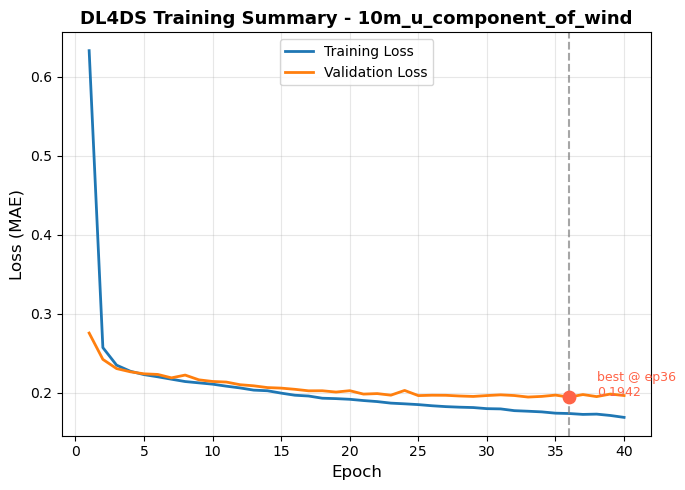


Final Training Loss: 0.168509
Final Validation Loss: 0.196203


In [ ]:
# Save chart config
plot_var = var_names[0]
history = trainers[plot_var].fithist.history

_chart1_cfg = {
    'chart': 'training_curves',
    'variable': plot_var,
    'figsize': [7, 5],
    'best_epoch': int(np.argmin(history['val_loss']) + 1),
    'best_val_loss': float(min(history['val_loss'])),
}
_json.dump(_chart1_cfg, open(os.path.join(RUN_DIR, 'chart_training_curves_config.json'), 'w'), indent=2)
_log('Chart config saved -> chart_training_curves_config.json')

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
epochs_range = range(1, len(history['loss']) + 1)

ax1.plot(epochs_range, history['loss'], label='Training Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], label='Validation Loss', linewidth=2)

best_epoch = np.argmin(history['val_loss']) + 1
best_loss = min(history['val_loss'])
ax1.axvline(best_epoch, color='gray', linestyle='--', alpha=0.7)
ax1.scatter([best_epoch], [best_loss], color='tomato', zorder=5, s=80)
ax1.annotate(
    f"best @ ep{best_epoch}\n{best_loss:.4f}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 2, best_loss + 0.002),
    fontsize=9,
    color='tomato',
)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (MAE)', fontsize=12)
ax1.set_title(f'DL4DS Training Summary - {plot_var}', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'sc1_dl4ds_training_curves.png', dpi=150)
plt.show()

print(f"\nFinal Training Loss: {history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.6f}")


[2026-04-29 19:21:56] Chart config saved -> chart_spatial_eval_config.json
[2026-04-29 19:22:07] Chart saved -> runs/20260429_174732_sc1_dl4ds/sc1_dl4ds_eval_2022-08-01.png


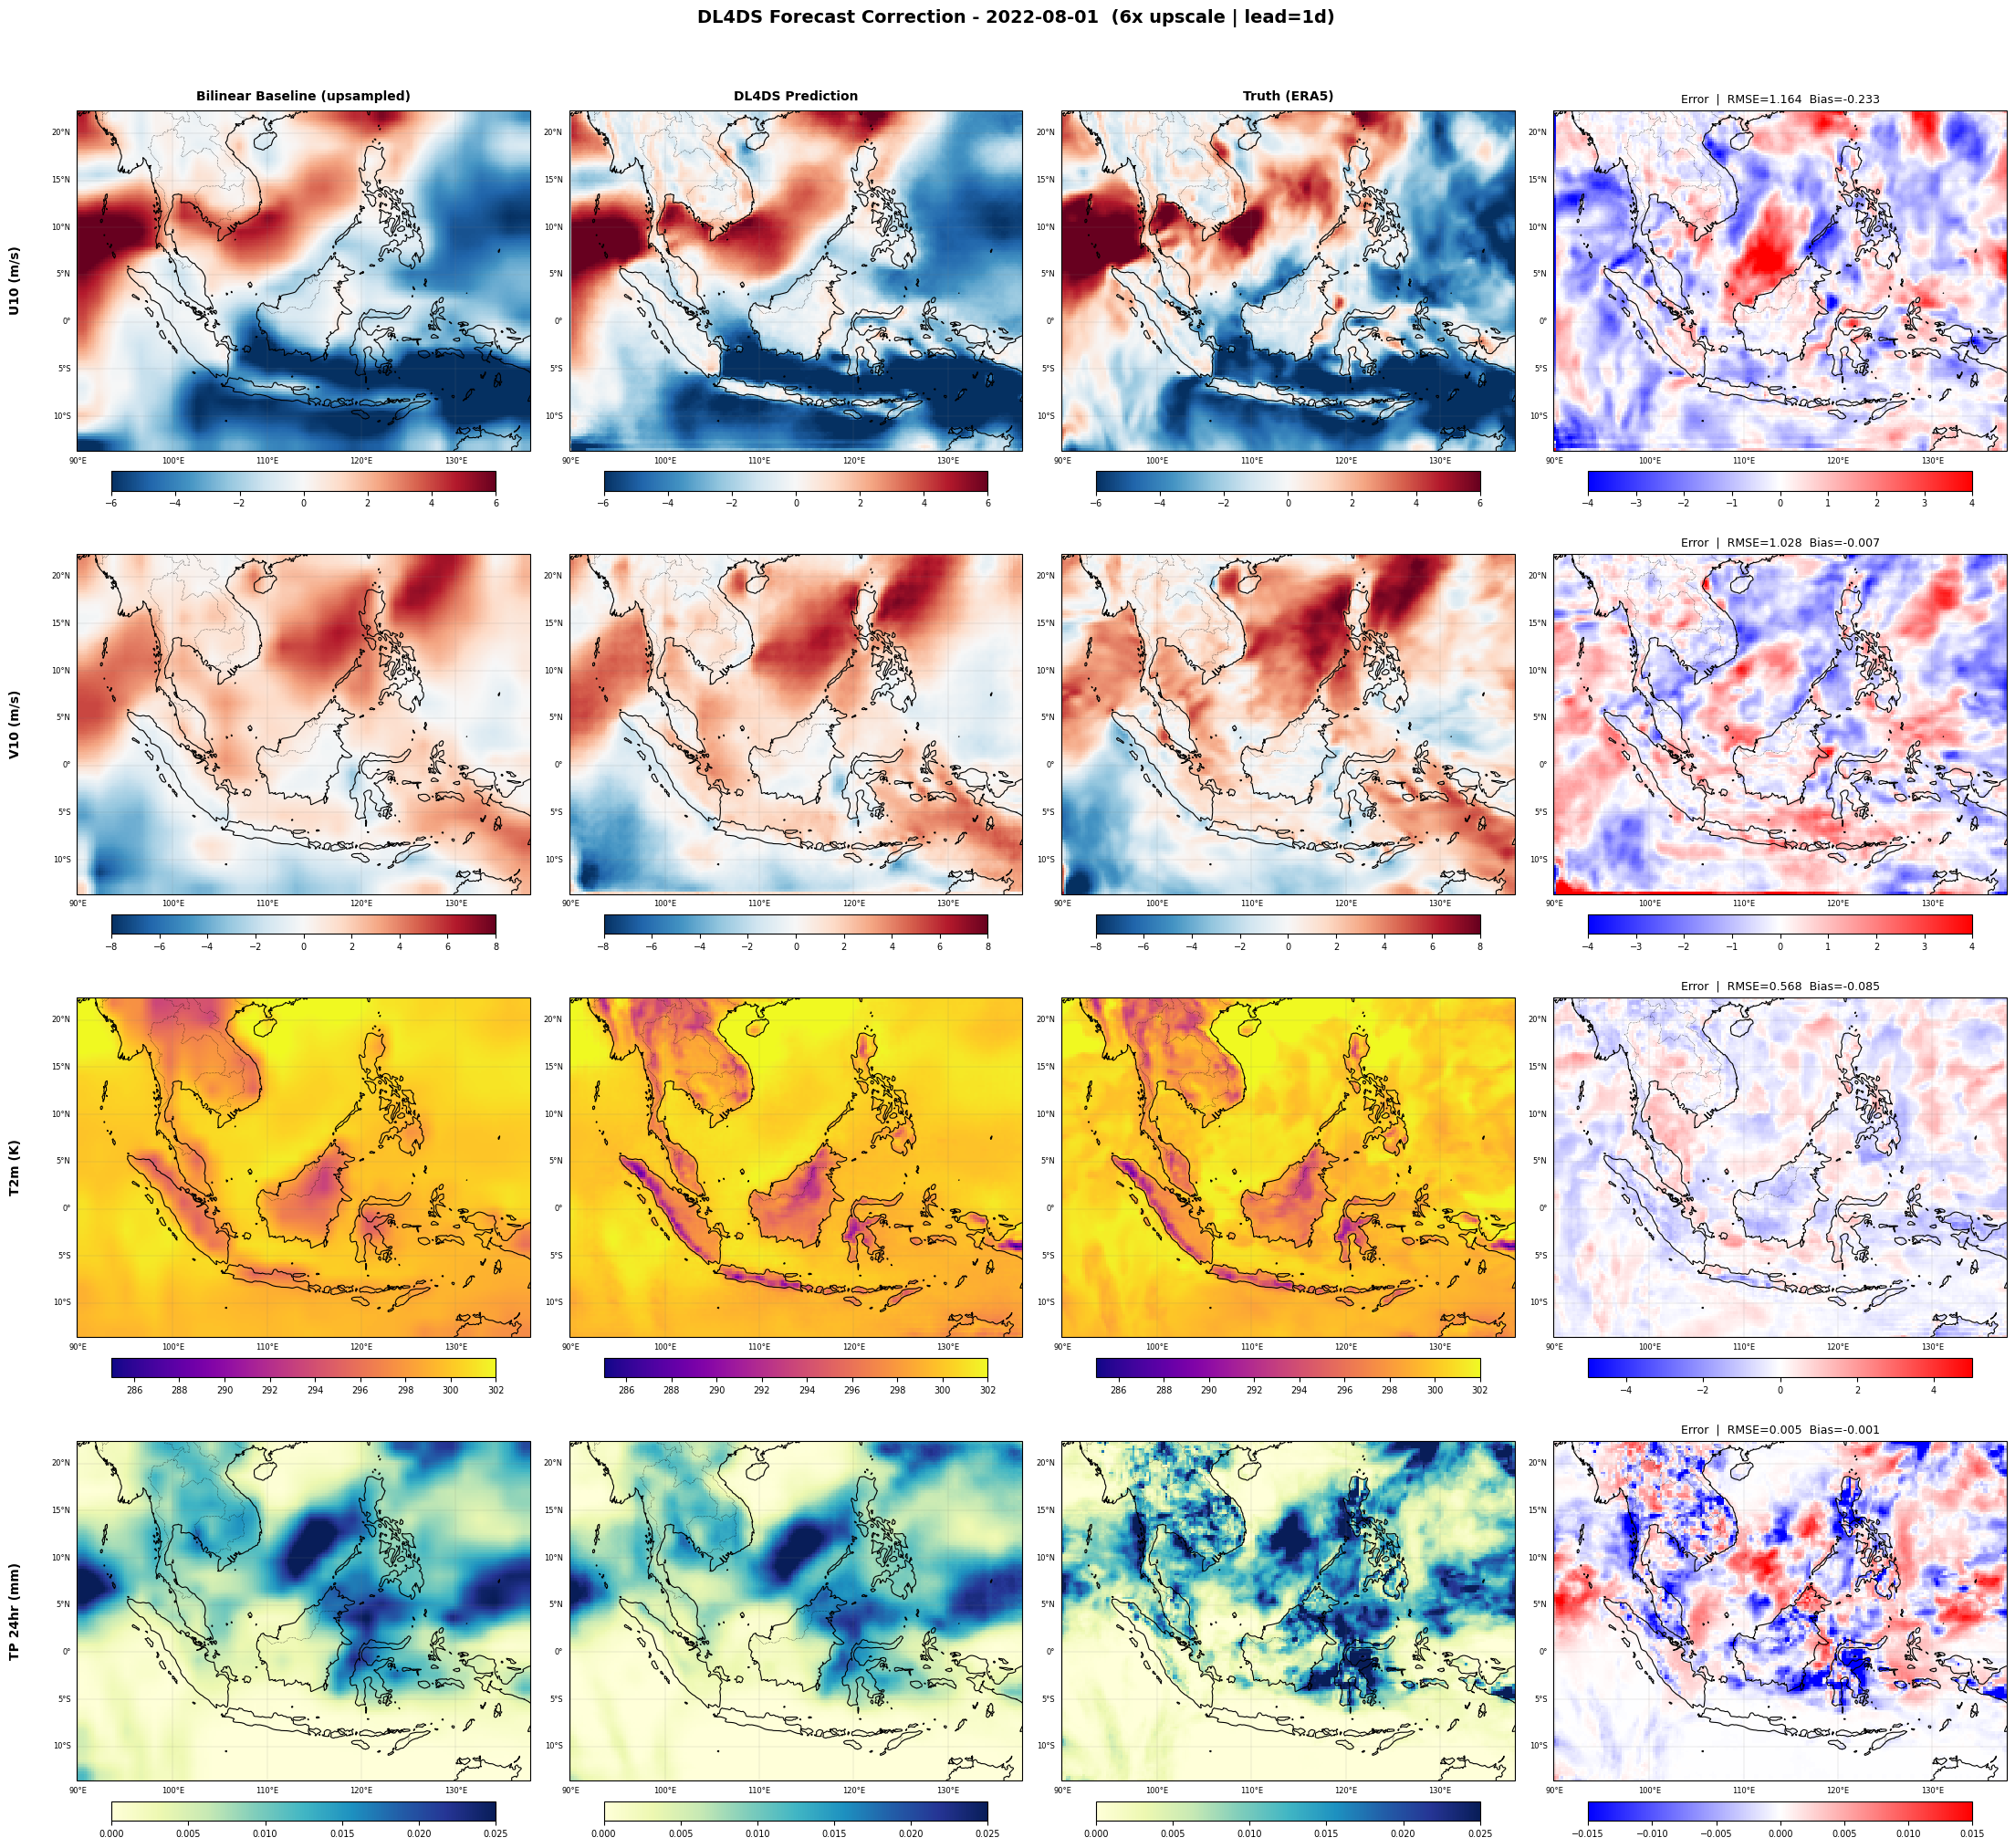

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    _HAS_CARTOPY = True
except ImportError:
    ccrs = None
    cfeature = None
    _HAS_CARTOPY = False
    print('Cartopy not available; plotting without map features.')

# Hardcoded color ranges for consistent head-to-head comparison.
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]
cmaps_field = ['RdBu_r', 'RdBu_r', 'plasma', 'YlGnBu']

if 'target_date' not in globals():
    target_date = np.datetime64('2022-08-01')

_chart2_cfg = {
    'chart': 'spatial_eval',
    'target_date': str(target_date),
    'lead_days': int(lead_days),
    'figsize': [22, 20],
    'FIELD_VMIN': FIELD_VMIN,
    'FIELD_VMAX': FIELD_VMAX,
    'ERROR_LIM': ERROR_LIM,
    'VAR_LABELS_VIZ': var_names,
    'cmaps_field': cmaps_field,
}
_json.dump(_chart2_cfg, open(os.path.join(RUN_DIR, 'chart_spatial_eval_config.json'), 'w'), indent=2)
_log('Chart config saved -> chart_spatial_eval_config.json')

ref_var = var_names[0]
test_times = data[ref_var]['test_target_orig'].time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} -> {test_times[-1]}"
    )
idx = int(idx[0])

predictions = {}
for var in var_names:
    model = trainers[var].model
    mean_val = norm_stats[var]['mean']
    std_val = norm_stats[var]['std']

    x_norm = data[var]['test_input'].isel(time=idx).values
    y_true = data[var]['test_target_orig'].isel(time=idx).values[:, :, 0]

    y_pred_norm = model.predict(np.expand_dims(x_norm, axis=0), verbose=0)[0]
    y_pred = y_pred_norm[:, :, 0] * std_val + mean_val

    if y_pred.shape != y_true.shape:
        if y_pred.shape == y_true.shape[::-1]:
            y_true = y_true.T
        else:
            raise ValueError(f'Spatial mismatch for {var}: pred {y_pred.shape} vs true {y_true.shape}')

    x_up = tf.image.resize(
        np.expand_dims(data[var]['test_input_orig'].isel(time=idx).values, axis=0),
        [y_pred.shape[0], y_pred.shape[1]],
        method='bilinear',
    )[0].numpy()[:, :, 0]

    predictions[var] = {
        'raw': x_up,
        'pred': y_pred,
        'true': y_true,
    }

lons_hr = data[ref_var]['test_target_orig'].longitude.values
lats_hr = data[ref_var]['test_target_orig'].latitude.values

n_vars = len(var_names)
col_titles = [
    'Bilinear Baseline (upsampled)',
    'DL4DS Prediction',
    'Truth (ERA5)',
    'Error (Pred - Truth)',
]

subplot_kw = {'projection': ccrs.PlateCarree()} if _HAS_CARTOPY else {}
proj = ccrs.PlateCarree() if _HAS_CARTOPY else None
fig, axes = plt.subplots(n_vars, 4, figsize=(22, 5 * n_vars), subplot_kw=subplot_kw)
if n_vars == 1:
    axes = np.expand_dims(axes, axis=0)

for v, var_name in enumerate(var_names):
    raw_v = predictions[var_name]['raw']
    pred_v = predictions[var_name]['pred']
    true_v = predictions[var_name]['true']
    err_v = pred_v - true_v

    cmap_f = cmaps_field[v] if v < len(cmaps_field) else 'viridis'
    vmin = FIELD_VMIN[v] if v < len(FIELD_VMIN) else float(np.nanmin([raw_v.min(), pred_v.min(), true_v.min()]))
    vmax = FIELD_VMAX[v] if v < len(FIELD_VMAX) else float(np.nanmax([raw_v.max(), pred_v.max(), true_v.max()]))
    elim = ERROR_LIM[v] if v < len(ERROR_LIM) else float(np.nanpercentile(np.abs(err_v), 99))

    panels = [
        (raw_v, cmap_f, vmin, vmax),
        (pred_v, cmap_f, vmin, vmax),
        (true_v, cmap_f, vmin, vmax),
        (err_v, 'bwr', -elim, elim),
    ]

    for col, (field, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]
        if field.shape != (len(lats_hr), len(lons_hr)):
            field = field.T

        pcolor_kwargs = {'cmap': cmap, 'vmin': lo, 'vmax': hi, 'shading': 'nearest'}
        if _HAS_CARTOPY:
            pcolor_kwargs['transform'] = proj
        im = ax.pcolormesh(lons_hr, lats_hr, field, **pcolor_kwargs)

        if _HAS_CARTOPY:
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':')
            ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=0)
            ax.add_feature(cfeature.OCEAN, facecolor='lightcyan', zorder=0)
            gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {'size': 6}
            gl.ylabel_style = {'size': 6}
        else:
            ax.set_xlabel('Longitude')
            ax.set_ylabel('Latitude')

        cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight='bold', pad=8)
        if col == 0:
            label = VAR_LABELS[v] if v < len(VAR_LABELS) else var_name
            ax.text(-0.15, 0.5, label, transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='center', rotation=90)

    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(f'Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}', fontsize=9, pad=6)

fig.suptitle(
    f'DL4DS Forecast Correction - {str(target_date)[:10]}  ({scale}x upscale | lead={lead_days}d)',
    fontsize=14,
    fontweight='bold',
    y=1.01,
)
plt.tight_layout()
save_fig(fig, f"sc1_dl4ds_eval_{str(target_date)[:10]}.png", dpi=150)
plt.show()


In [ ]:
# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics, DL4DS Scenario 1)
# ==============================
import csv as _csv
import numpy as np
import xarray as xr

_var_to_label = {
    '10m_u_component_of_wind': 'U10 (m/s)',
    '10m_v_component_of_wind': 'V10 (m/s)',
    '2m_temperature': 'T2m (K)',
    'total_precipitation_24hr': 'TP 24hr (mm)',
}

fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

for v_name in var_names:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

baseline_rmse_by_var = {}
for v_name in var_names:
    low_da = fc_test_lowres[v_name].transpose('time', 'latitude', 'longitude')
    truth_da_xr = tr_test_ds[v_name].transpose('time', 'latitude', 'longitude')

    common_time = np.intersect1d(low_da.time.values, truth_da_xr.time.values)
    low_da = low_da.sel(time=common_time)
    truth_da_xr = truth_da_xr.sel(time=common_time)

    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )

    base_v_xr = base_da.values
    true_v_xr = truth_da_xr.values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print('\n' + '=' * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print('=' * 100)

BASELINE_EPS = 1e-8
_metrics_rows = []

for v_name in var_names:
    model = trainers[v_name].model
    mean_val = norm_stats[v_name]['mean']
    std_val = norm_stats[v_name]['std']

    n_test = len(data[v_name]['test_target'].time)
    pred_time = []
    true_time = []

    for j in range(n_test):
        x_norm = data[v_name]['test_input'].isel(time=j).values
        y_true = data[v_name]['test_target_orig'].isel(time=j).values[:, :, 0]

        y_pred_norm = model.predict(np.expand_dims(x_norm, axis=0), verbose=0)[0]
        y_pred = y_pred_norm[:, :, 0] * std_val + mean_val

        if y_pred.shape != y_true.shape:
            if y_pred.shape == y_true.shape[::-1]:
                y_true = y_true.T
            else:
                raise ValueError(f'Spatial mismatch for {v_name}: pred {y_pred.shape} vs true {y_true.shape}')

        pred_time.append(y_pred)
        true_time.append(y_true)

    pred_v = np.stack(pred_time, axis=0)
    true_v = np.stack(true_time, axis=0)

    n = min(pred_v.shape[0], true_v.shape[0])
    pred_v = pred_v[:n]
    true_v = true_v[:n]

    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = 1.0 - (rmse / rmse_base) if rmse_base > BASELINE_EPS else 0.0

    label = _var_to_label.get(v_name, v_name)
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

    _metrics_rows.append({
        'variable': v_name,
        'label': label,
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'Corr': corr,
        'Baseline_RMSE': rmse_base,
        'Skill': float(skill),
    })

print('=' * 100)
print('\nSkill > 0 means DL4DS improves over bilinear interpolation baseline.')

metrics_df = pd.DataFrame(_metrics_rows).sort_values('Skill', ascending=False).reset_index(drop=True)

metrics_path_sc1 = os.path.join(RUN_DIR, 'sc1_dl4ds_metrics.csv')
metrics_df.to_csv(metrics_path_sc1, index=False)
print(f'Saved: {metrics_path_sc1}')

_csv_path = os.path.join(RUN_DIR, 'metrics.csv')
_fields = ['variable', 'label', 'RMSE', 'MAE', 'Bias', 'Corr', 'Baseline_RMSE', 'Skill']
with open(_csv_path, 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    _w.writerows(_metrics_rows)

_log(f'Metrics saved -> {metrics_path_sc1}')
_log(f'Metrics saved -> {_csv_path}')

_total = _dt.datetime.now() - _run_start
_log(f"=== Run finished total_elapsed={str(_total).split('.')[0]} ===")
_log(f'All outputs in: {RUN_DIR}')
print(f'\nAll outputs saved to: {RUN_DIR}')



Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   1.1092 |   0.8406 |  -0.1272 |   0.8880 |         1.2424 |  +0.1072
V10 (m/s)          |   1.1172 |   0.8569 |  +0.0392 |   0.8550 |         1.1707 |  +0.0457
T2m (K)            |   0.5759 |   0.4526 |  -0.1131 |   0.8360 |         0.8176 |  +0.2957
TP 24hr (mm)       |   0.0064 |   0.0033 |  -0.0008 |   0.8144 |         0.0065 |  +0.0132

Skill > 0 means DL4DS improves over bilinear interpolation baseline.
Saved: runs/20260429_174732_sc1_dl4ds/sc1_dl4ds_metrics.csv
[2026-04-29 19:23:20] Metrics saved -> runs/20260429_174732_sc1_dl4ds/sc1_dl4ds_metrics.csv
[2026-04-29 19:23:20] Metrics saved -> runs/20260429_174732_sc1_dl4ds/metrics.csv
[2026-04-29 19:23:20] === Run finished total_elapsed=1:35:48 ===
[2026-04-29 19:23:20] All outputs in: runs/20260429_174732_sc1_dl4ds

All outputs saved to: runs/20260429_174732_sc1_dl4ds
